# On veut detecter les patches


In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

##   OpenCV detection

In [16]:
folderpath = "/data1/DATA_Duplat/Brut/Patch_detection/Pa1n6/"
file = "/data1/DATA_Duplat/Brut/Patch_detection/Pa1n6/Snapshots/nav7000000000_outputB.txt"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]

snapshot = np.zeros(L1*L2)  
sys_image = np.zeros((L1,L2))
with open(f'{file}', 'r') as f:

    j = 0
    for line in f :
        if not line.startswith('#'):
            col = line.strip().split("  ")
            snapshot[j] = col[0]
            j += 1
            
    
    for n in range (L1*L2):
        x1, x2 = coorno(n, L1)
        sys_image[x1][x2] = snapshot[n]

print(np.shape(sys_image))

# Exemple d'image : Remplace sys_image par ton tableau réel
sys_image_bis = (sys_image * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV


(256, 256)


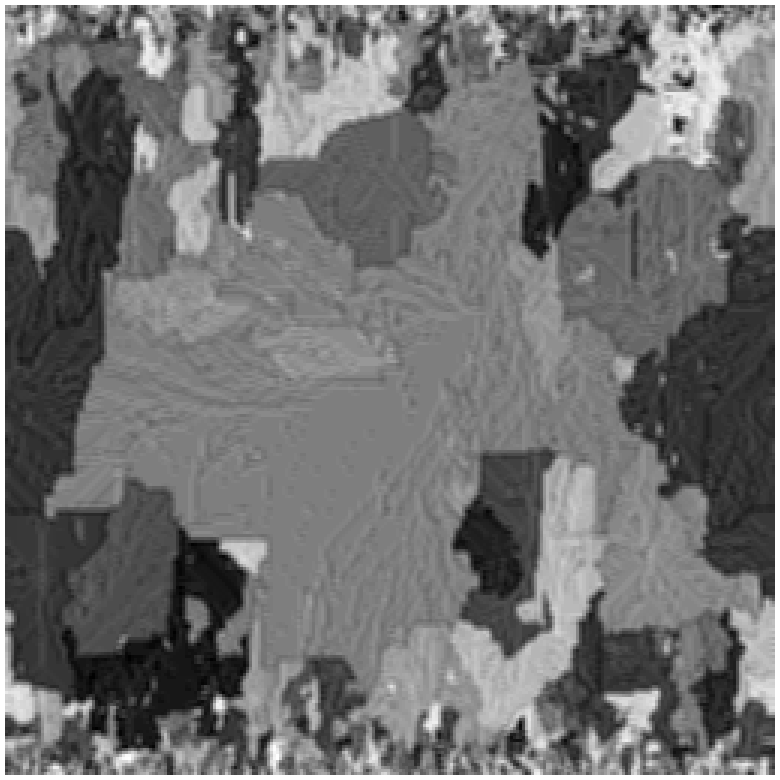

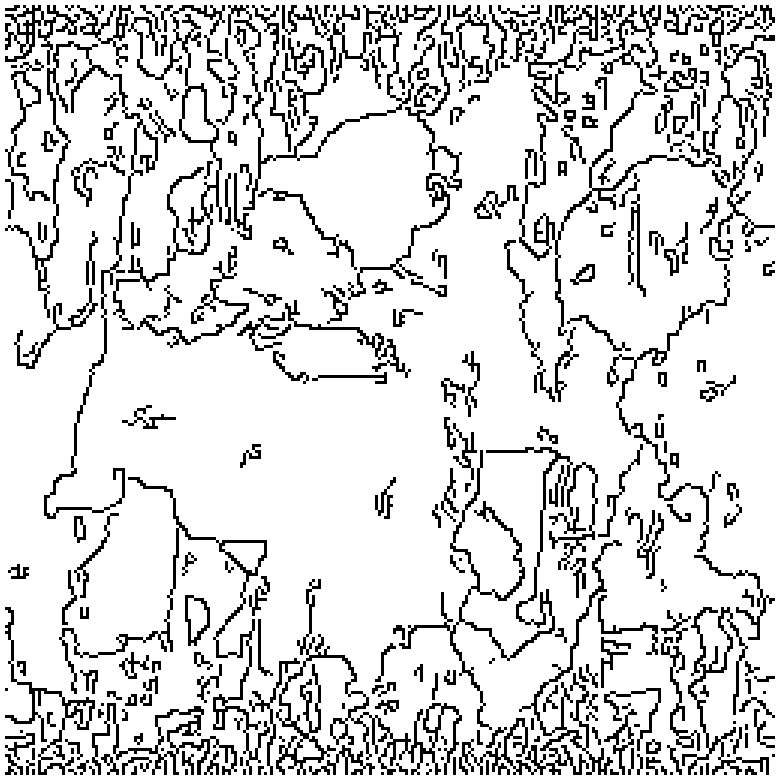

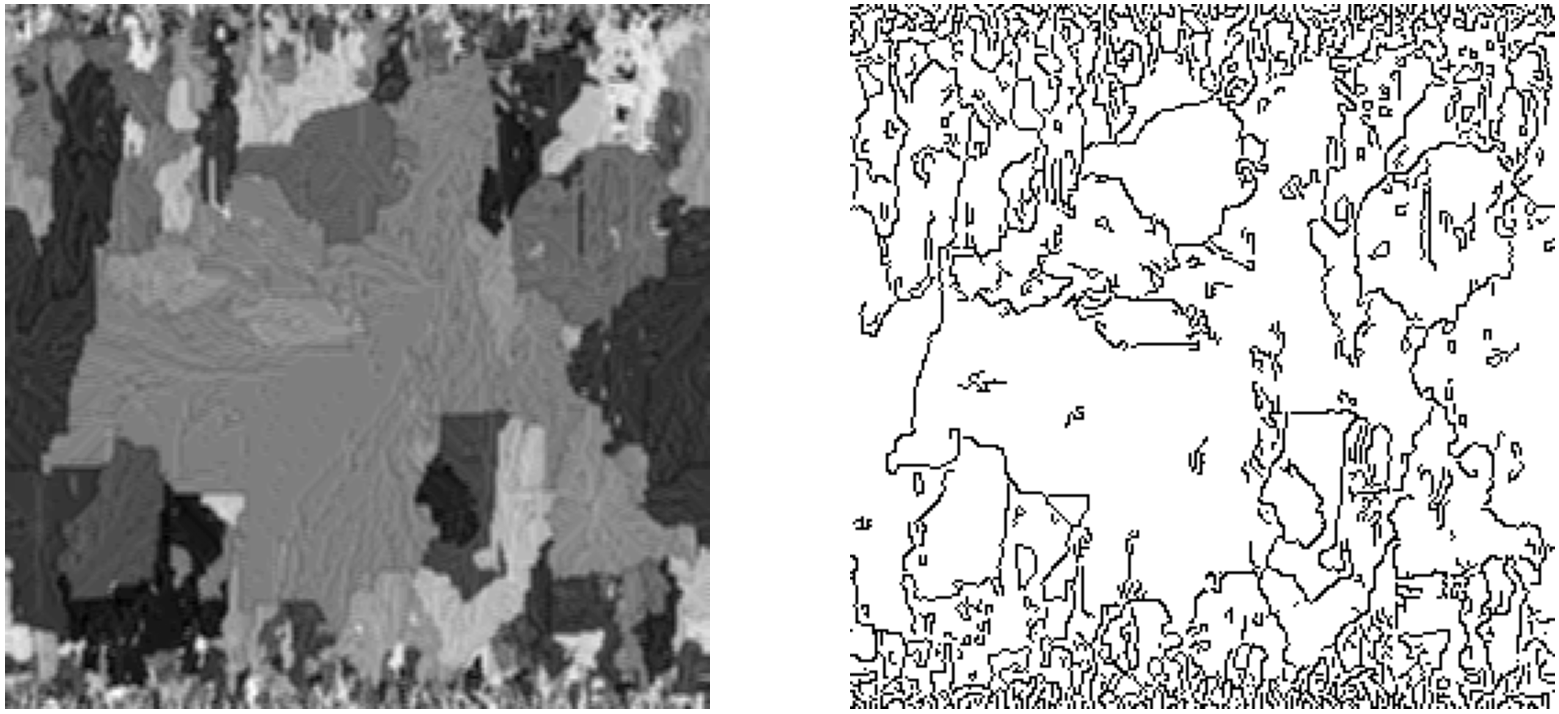

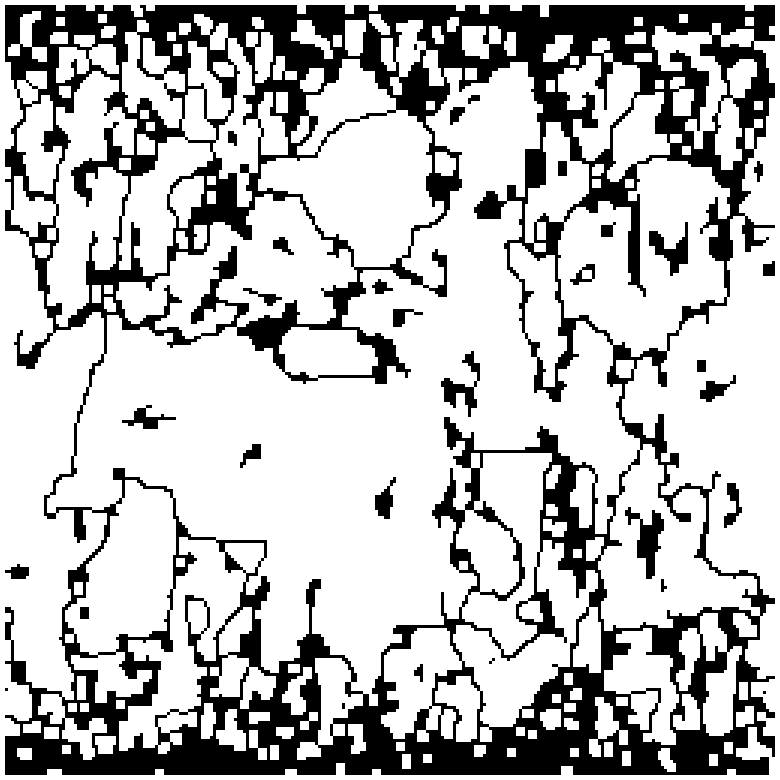

In [17]:
import cv2


# Gaussian blurring
# (5,5) est la taille du noyau gaussien, sigmaX et sigmaY sont les écarts-types des noyaux gaussiens dans les directions x et y.
# Le noyau gaussien est une matrice appliqué à l'image pour lisser les détails de l'image.
blurred_image = cv2.GaussianBlur(sys_image_bis, (3, 3), sigmaX = 1, sigmaY = 10)


# Edge detection
# Gradiant under th1 are ignored
edges = cv2.Canny(blurred_image, threshold1=45, threshold2=100)

# print(edges)

# Trouver les contours dans l'image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

kernel = np.ones((3, 3), np.uint8)
closed_image = cv2.morphologyEx(contour_image, cv2.MORPH_CLOSE, kernel)

# print(contours)

# Initialiser une liste pour stocker les tailles des zones
zone_sizes = []
# Calculer le nombre de pixels à l'intérieur de chaque zone
for contour in contours:
    mask = np.zeros_like(sys_image_bis)  # Créer une image vide
    cv2.drawContours(mask, [contour], -1, (255), thickness=cv2.FILLED)  # Remplir la zone
    size = np.sum(mask == 255)  # Compter les pixels blancs
    zone_sizes.append(size)


histo, bins = np.histogram(zone_sizes)


# Créer une image pour dessiner les contours
contour_image = np.zeros_like(sys_image)

# Dessiner les contours détectés
cv2.drawContours(contour_image, contours, -1, (255), 1)  # Dessiner en blanc (255)

kernel = np.ones((3, 3), np.uint8)
closed_image = cv2.morphologyEx(contour_image, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(10, 10))
plt.imshow(blurred_image, cmap = "binary")
plt.axis("off")
plt.show()
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap = "binary")
plt.axis("off")
plt.show()
# Afficher les résultats
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(blurred_image, cmap='binary')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contour_image, cmap='binary')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(closed_image, cmap = "binary")
plt.axis("off")
plt.show()

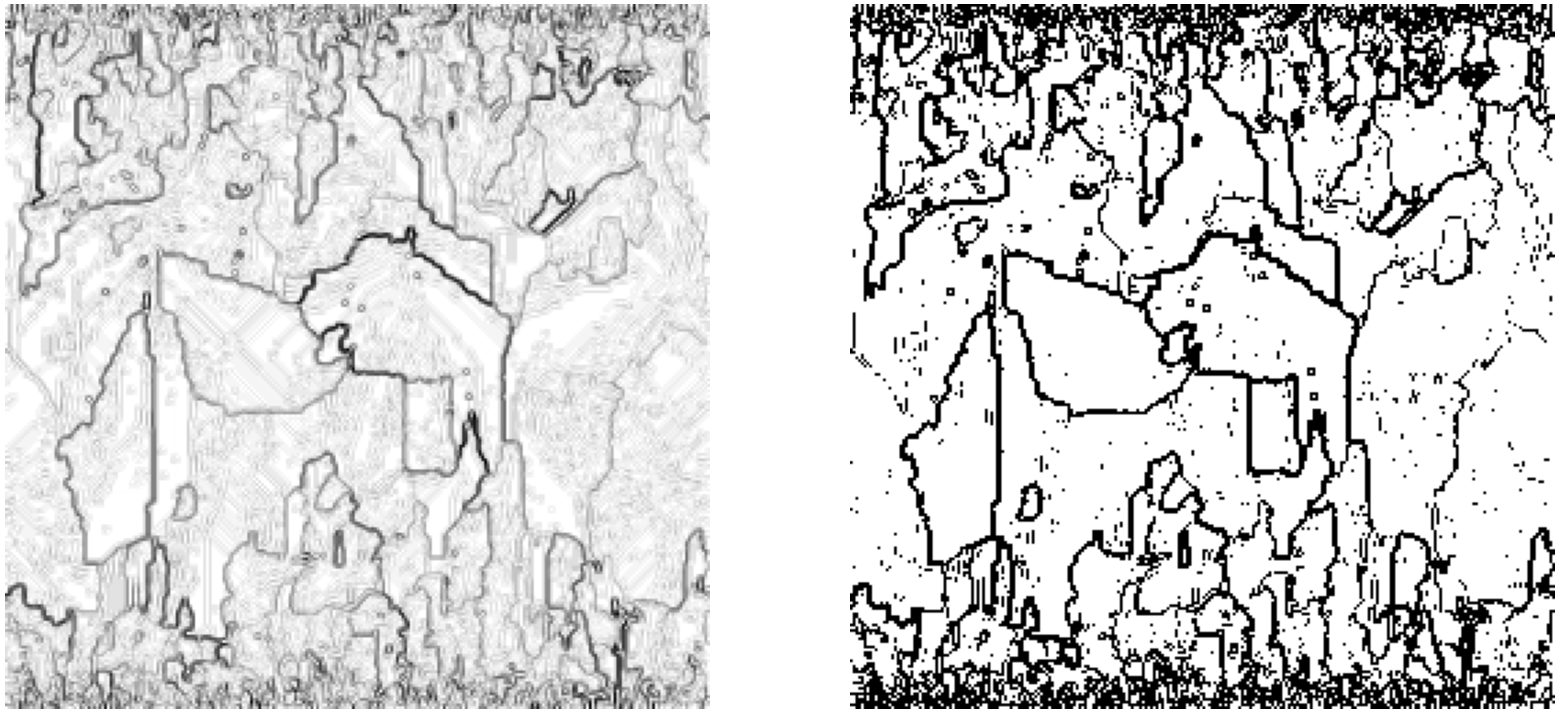

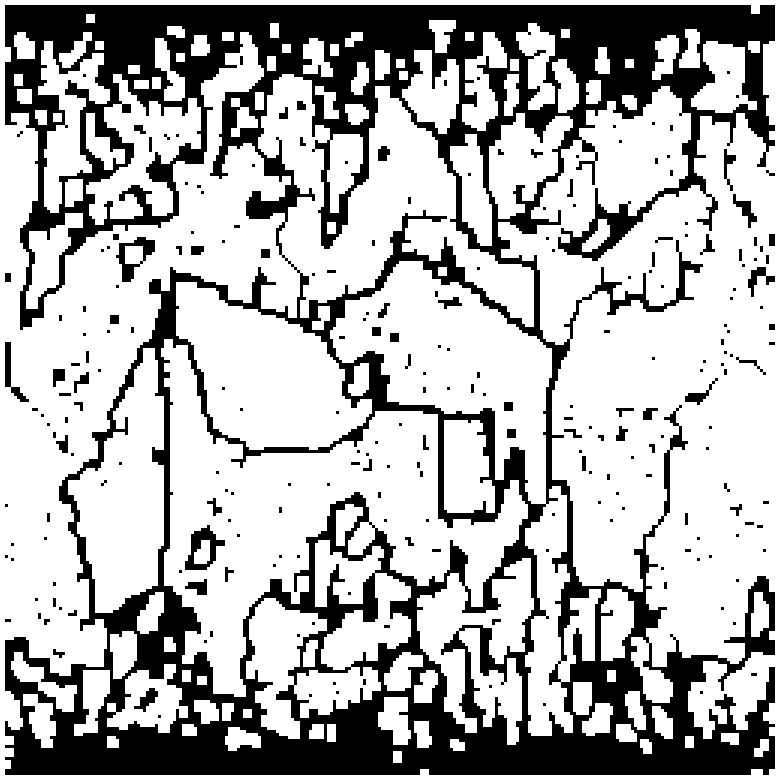

In [12]:
# Appliquer le filtre de Sobel
sobelx = cv2.Sobel(sys_image_bis, cv2.CV_64F, 1, 0, ksize=3)  # Gradient en x
sobely = cv2.Sobel(sys_image_bis, cv2.CV_64F, 0, 1, ksize=3)  # Gradient en y

# Combinaison des gradients
sobel_combined = cv2.magnitude(sobelx, sobely)

# Normalisation pour affichage
sobel_combined = cv2.normalize(sobel_combined, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Affichage des résultats
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(sobel_combined, cmap='binary')
plt.axis('off')
# Binarisation
_, binary_image = cv2.threshold(sobel_combined, 50, 255, cv2.THRESH_BINARY)

# Opérations morphologiques pour fermer les contours
kernel = np.ones((3, 3), np.uint8)
closed_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

# Affichage
plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap='binary')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(closed_image, cmap='binary')
plt.axis('off')
plt.show()


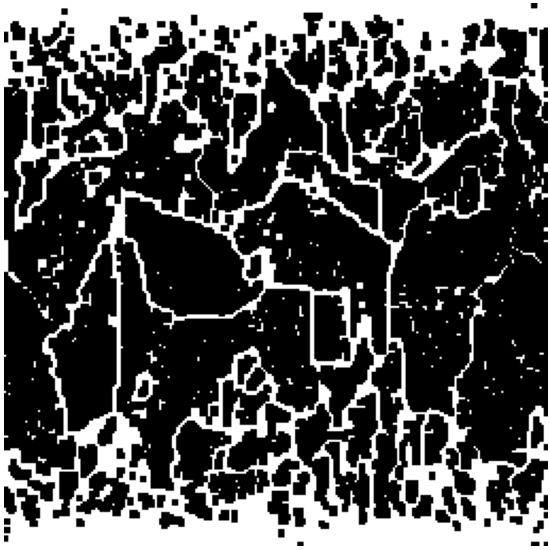

In [25]:
# Charger les deux images (si elles ne sont pas encore en mémoire)
# image_clean: Image avec des patches propres mais non fermés
# image_closed: Image avec des bords fermés mais avec des imperfections

# Binarisation si nécessaire
_, binary_closed = cv2.threshold(closed_image, 50, 255, cv2.THRESH_BINARY)

# Afficher les images binarisées
plt.figure(figsize=(10, 10))
plt.imshow(binary_closed, cmap='gray')
plt.axis('off')
plt.show()

## First method

In [87]:
import numpy as np
import cv2
from skimage import filters, measure
from skimage.draw import polygon
from skimage.filters import threshold_multiotsu, threshold_otsu
from scipy import ndimage

def patch_id(patch_rescaled, nbclasse=5, blur=3, switch=1):
    # Appliquer un filtre Gaussien une seule fois pour toute l'image
    image = cv2.GaussianBlur(patch_rescaled, (blur, blur), sigmaX=0, sigmaY=0)

    # Application du seuil multi-Otsu pour générer des classes
    thresholds = threshold_multiotsu(image, classes=nbclasse)
    regions = np.digitize(image, bins=thresholds)
    
    
    if switch:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(patch_rescaled, cmap='binary')

    allcontours = []
    covered_regions = np.zeros_like(regions)
    
    NCURVES = nbclasse + 1
    cmap = plt.cm.get_cmap('inferno')
    colors = [cmap(i / NCURVES) for i in range(NCURVES)]
    
    # Boucle sur chaque classe pour obtenir les contours
    for i in range(0, nbclasse + 1):  # Remarquez l'indice i, pour travailler directement avec la classe
        mask = regions == i  # Créez un masque pour chaque classe

        # Appliquer un filtre Gaussien sur l'image masquée
        smoothed_image = filters.gaussian(mask, sigma=1) #Avoid to take borders as patches

        if np.sum(mask) > 0:  # Si la classe a des valeurs
            # Segmentation avec un seuil multi-Otsu sur l'image lissée
            # thresholds = threshold_otsu(smoothed_image)
            # segmented_image = np.digitize(smoothed_image, bins=thresholds) #Transforme les valeurs d'entrée en entier
            
            original = smoothed_image
            thres = threshold_otsu(smoothed_image) #Find a threshold between background and the class
            segmented_image = original > thres
        
            
            # Étiqueter les régions connectées
            labeled_image, num_labels = ndimage.label(segmented_image)

            # Trouver les contours
            contours = measure.find_contours(labeled_image, level=0.5)

            for contour in contours:
                allcontours.append(contour)
                covered_regions[mask] = 1
                if switch: 
                    ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red', alpha=0.5)
                
            # plt.axis('off')
            # plt.show()
                    

    
    if switch: 
        ax.axis('off')
        plt.show()

    # Calculer les tailles des domaines
    domain_sizes = []
    for contour in allcontours:
        contour = np.array(contour, dtype=int)  # Convertir en entiers

        # Créer un masque vide (même taille que l'image originale)
        mask = np.zeros_like(regions, dtype=bool)

        # Obtenir les coordonnées du polygone et remplir le masque
        rr, cc = polygon(contour[:, 0], contour[:, 1], shape=mask.shape)
        mask[rr, cc] = True

        # Calculer directement la taille du domaine avec la somme des pixels dans le masque
        domain_sizes.append(np.sum(mask))
        

    return domain_sizes

In [85]:

import cv2

# /data1/DATA_Duplat/Brut/Ava_track/Av2n12/Snapshots/nav1602900005522_outputB.txt
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD1n14/"
L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]


file ="/data1/DATA_Duplat/Brut/Patch_detection/Pa1n6/Snapshots/nav526000000000_outputB.txt"
snapshot = np.zeros(L1*L2)  
sys_image = np.loadtxt(f'{file}', comments='#').reshape(L1, L2).T

print(np.shape(sys_image))

# Exemple d'image : Remplace sys_image par ton tableau réel
sys_image_bis = (sys_image * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

(256, 256)


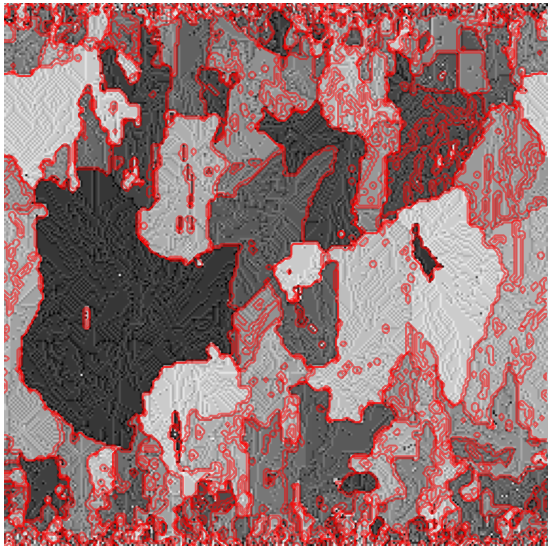

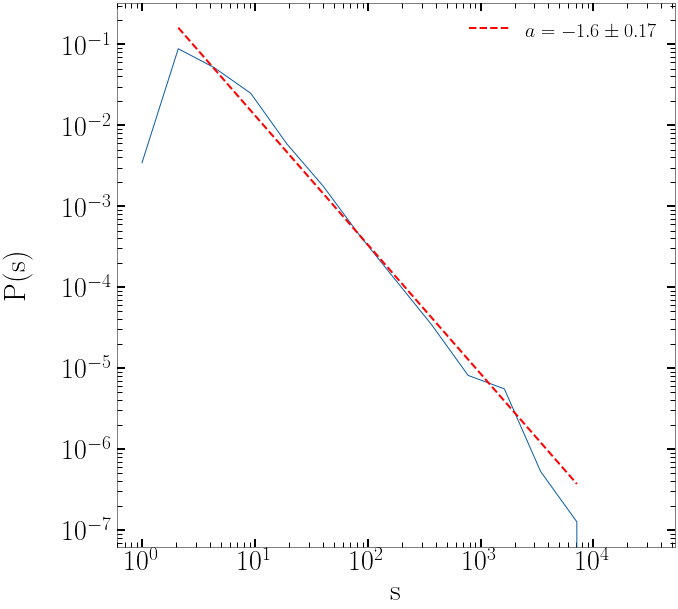

In [88]:
domain_sizes = patch_id(sys_image_bis, nbclasse = 5, blur = 3, switch = 1)

nbins = 15

lin_bins = np.arange(0, L1 * L2)
histo = np.histogram(domain_sizes, bins=lin_bins)[0]

log_bins = np.logspace(np.log10(1), np.log10(L1 * L2), nbins+1)
log_histo = np.zeros(nbins)
norm_histo = histo / np.sum(histo)

for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
    # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
    overlap = (lin_bins[:-1] >= log_bins[i]) & (lin_bins[:-1] < log_bins[i + 1])
    # Ajouter les comptages de ces bins linéaires au bin logarithmique
    if len(norm_histo[overlap])!=0:
        log_histo[i] = np.sum(norm_histo[overlap])/len(norm_histo[overlap])
        # log_histo[i] = np.sum(data[overlap])


bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
log_histo_normalized = log_histo / area  # Normalisation


mask = log_histo_normalized!= 0
filt_hist = log_histo_normalized[mask]
filt_bins = log_bins[:-1][mask]

result, xs, _ , perr = fit_powerlaw(filt_bins, filt_hist, start_x = 1, stop_x = 5e-5,  plot=True, f_scale=1.0,
                                    function_to_fit='power')

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(log_bins[:-1],log_histo_normalized)
ax.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                         np.round(perr[1], 2)))
para_fig(ax, "s", "P(s)", "loglog")
ax.legend(fontsize = 20)
plt.show()



##  Regionprops equivalent "https://stackoverflow.com/questions/51249781/using-regionprops-in-python "

In [2]:
def class_contrast(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    means = [np.mean(image[regions == i]) for i in range(len(thresholds) + 1)]
    contrast = np.std(means)  # Dispersion des moyennes
    return contrast

def otsu_criterion(image, thresholds):
    """
    Calcule la variance intra-classe totale après seuillage multi-Otsu.
    Plus cette valeur est faible, meilleure est la séparation des classes.
    """
    regions = np.digitize(image, bins=thresholds)
    total_variance = 0
    
    for i in range(len(thresholds) + 1):
        mask = regions == i
        if np.any(mask):
            variance = np.var(image[mask])
            total_variance += variance
    
    return total_variance

def snr_metric(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    foreground = image[regions > 0]  # Patches détectés
    background = image[regions == 0]  # Fond

    signal = np.mean(foreground)
    noise = np.std(background) if np.any(background) else 1  # Éviter division par 0

    return signal / noise

def optimal_thresholds_BIC(image, max_k=5):
    N = image.size
    BIC_scores = []
    
    for k in range(1, max_k+1):
        thresholds = threshold_multiotsu(image, classes=k+1)
        segmented = np.digitize(image, bins=thresholds)

        # Variance intra-classe
        sigma_W = np.mean([np.var(image[segmented == i]) for i in range(k+1)])

        # Calcul du BIC
        BIC = N * np.log(sigma_W + 1e-8) + k * np.log(N)
        BIC_scores.append(BIC)

    # Sélection du k qui minimise le BIC
    best_k = np.argmin(BIC_scores) + 1
    return best_k

from kneed import KneeLocator

def find_elbow_thresholds(image, max_k=5):
    variances = []
    fig, ax = plt.subplots(figsize = (10,10))
    for k in range(1, max_k+1):
        thresholds = threshold_multiotsu(image, classes=k+1)
        segmented = np.digitize(image, bins=thresholds)
        var_inter = np.std([np.mean(image[segmented == i]) for i in range(k+1)])
        variances.append(var_inter)
    
    plt.plot(range(1, max_k+1), variances, marker='o')
    plt.show()
    kneedle = KneeLocator(range(1, max_k+1), variances, curve="concave", direction="increasing")
    return kneedle.elbow


from matplotlib.path import Path
def otsu_detection(nbclasse, image, m_size, sigma_X, sigma_Y, mode_switch, min_nbclass = 2):
    max_interclasse = 0
    min_intraclasse = 1e12
    max_nbclasse = 0
    
    """ blurred_image = cv2.GaussianBlur(image, (m_size, m_size), sigmaX = sigma_X, sigmaY = sigma_Y) """
    blurred_image  = cv2.medianBlur(image, 5)
    
    #Find the best number of classes
    for n in range(min_nbclass, nbclasse + 1):
        thresholds = threshold_multiotsu(blurred_image[image!=0], classes = n)
        if mode_switch == 0:
            contrast = class_contrast(image, thresholds)
            if contrast > max_interclasse:
                max_interclasse = contrast
                max_nbclasse = n
                
        elif mode_switch == 1:
            intra_std = otsu_criterion(image, thresholds)
            if intra_std < min_intraclasse:
                min_intraclasse = intra_std
                max_nbclasse = n
        else:
            raise ValueError("otsu_detection mode_switch must be 0 or 1")
    # max_nbclasse = 5
    return cluster_detection(blurred_image, max_nbclasse)

def contours_to_label_fct(labeled_image, contours, num_features):
    L1 = labeled_image.shape[0]
    L2 = labeled_image.shape[1]
    ##########External contour##########
    contour_to_label = []
    for j, contour in enumerate(contours):  
        external_path = Path(contour)
        for k in range(1,num_features + 1):
            patch = np.argwhere(labeled_image == k)
            inside = external_path.contains_points(patch)
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label.append([j, k])
                # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=1)
                break
        else: 
            contour_to_label.append([j, -1]) #Si aucun élément n'est contenu dans le contour, c'est un contour interieur    
            # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="blue", alpha=1)  

    ##########Internal contour##########
    contour_to_label = np.array(contour_to_label)
    mask = contour_to_label[:,1] == -1

    for _, int_id_contour in enumerate(contour_to_label[mask][:,0]):
        for _, (id_contour, idpatch) in enumerate(contour_to_label[~mask]):
            external_path = Path(contours[id_contour])
            inside = external_path.contains_points(contours[int_id_contour])
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label[int_id_contour,1] = idpatch 
                # ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=2, color="green", alpha=1)
                break
        else:
            for point in contours[int_id_contour]:
                y, x = np.floor(point).astype(int)

                neighbors = [(y+1, x), (y-1, x), (y, x+1), (y, x-1)]
                for y_neighbor, x_neighbor in neighbors: 
                    if 0 <= x_neighbor < L1 and 0 <= y_neighbor < L2:
                        label_val = labeled_image[y_neighbor, x_neighbor]
                        if label_val:
                            contour_to_label[int_id_contour, 1] = label_val
                            break

                    
        if contour_to_label[int_id_contour,1] == -1:
            print("A contour is not linked to a cluster, id_contour = {}".format(int_id_contour))
        """     ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="orange", alpha=1)
        else :
            ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="green", alpha=1) """
    
    #Change the contour_id to the patch_id since it will be the same in all_contours_to_label and all_contours 
    return contour_to_label


def cluster_detection(blurred_image, nbclass):
    feature_areas = []
    all_contours = []
    all_labeled_image = []
    
    thresholds = threshold_multiotsu(blurred_image[blurred_image!=0], classes = nbclass)#Find the thresholds
    regions = np.digitize(blurred_image, bins=thresholds)
    all_contours_to_label = []
    
    for i in range (0, nbclass):
        # print(i)
        mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
        masked_image = np.where(mask, 1, -1)

        smoothed_image = filters.gaussian(masked_image, sigma=1) #Allow to fill the possible holes in the clusters
        
        original = smoothed_image
        thres = threshold_otsu(smoothed_image) #Find a threshold between background and the class
        binary = original > thres

        binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
        labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
        feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions (ravel aplati le tableau)
        all_labeled_image.append(labeled_image)

        contours = measure.find_contours(binary_closed, level=0.5)
        all_contours.extend(contours)
    
        ##########Link contours to labeled clusters##########

        contours_to_label = contours_to_label_fct(labeled_image, contours, num_features)
        contours_to_label[:,0] = i
        all_contours_to_label.extend(contours_to_label)  
        
        
        
    return np.array(feature_areas), np.array(all_contours), np.array(all_labeled_image), thresholds, np.array(all_contours_to_label)


def second_detection(image, all_contours, all_labeled_image, all_contours_to_label):
    print("*************SECOND DETECTION")
    new_contours = np.copy(all_contours)
    new_labeled_image  = np.copy(all_labeled_image)
    new_contours_to_label = np.copy(all_contours_to_label)
    new_featured_areas = []
    new_thresholds = []
    contour_contained = []
    
    extra_contours = []
    extra_labeled_images = []
    extra_contours_to_label = []
    
    switch = 0
    for j, labeled_image in enumerate(all_labeled_image):
        
        sizes = np.bincount(labeled_image.ravel())
        mask_label = np.where(sizes > 7000)[0]
        mask_label = mask_label[mask_label != 0]
        
        for i in mask_label:
            mask = labeled_image == i
            f_image = np.zeros_like(image)
            f_image[mask] = image[mask]
            if (np.std(f_image[mask]) >= 20):
                
                blurred_sys2 = cv2.medianBlur(f_image, 7)
                # blurred_sys2[~mask] = 0

                try :
                    feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = otsu_detection(5, blurred_sys2, 1,0,0, 1, min_nbclass = 5)
                except ValueError:
                    feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = otsu_detection(4, blurred_sys2, 1,0,0, 1, min_nbclass = 4)

                id_contour = np.argwhere(np.all(all_contours_to_label == [j, i], axis = 1)) #Find the biggest external contour
                contours = all_contours[id_contour[0,0]]
                contour_contained.append(id_contour[0,0])
                
                
                external_path = Path(contours)
                for k, contour in enumerate(all_contours):  #Find all inside contour to delete them
                    if k == id_contour[0,0]: 
                        continue
                    inside = external_path.contains_points(contour)
                    if (np.sum(inside)/len(inside) > 0.5): #Au moins un élément dans être contenu dans le contour
                        contour_contained.append(k)
                if(len(contour_contained) == 0): 
                    print("Error, no contour contained") #Si aucun élément n'est contenu dans le contour, c'est un contour interieur
                    print(contour_contained)
                    
                ######Find the index linked to the empty space######
                id_emptysys = np.argwhere(np.all(contour_to_label2[:] == [0,1], axis = 1))[:,0] 
                
                if np.any(np.all(contour_to_label2[:] == [0,2], axis = 1)): 
                    id_emptysys_bis = np.argwhere(np.all(contour_to_label2[:] == [0,2], axis = 1))[0,0]
                    id_emptysys = np.append(id_emptysys, id_emptysys_bis)
                
                mask2 = all_labeled_image2[0] == 1  
                all_labeled_image2[0][mask2] = 0 #Remove the empty space considered as a patch
                mask3 = np.ones(len(contour_to_label2), dtype = bool)
                mask3[id_emptysys] = False
                #To avoid taking into account small patches created at the boundary, I apply a threshold on the size for the new detection
                for l, label in enumerate(all_labeled_image2):
                    
                    new_sizes = np.bincount(label.ravel())
                    new_mask_label = np.where(new_sizes < 700)[0]
                    for k in new_mask_label:
                        id = np.argwhere(np.all(contour_to_label2[:] == [l,k], axis = 1))[:,0]
                        mask4 = all_labeled_image2[l] == k
                        all_labeled_image2[l][mask4] = 0
                        mask3[id] = False

                extra_contours.append(all_contours2[mask3]) #Add the new ones to the list
                contour_to_label2[:,0] += (len(new_labeled_image) + len(extra_labeled_images))
                extra_contours_to_label.append(contour_to_label2)
                extra_labeled_images.append(all_labeled_image2)
                new_thresholds.append(thresholds2)
                
    if extra_contours:
        new_contours = np.concatenate([new_contours] + extra_contours, axis=0)
        new_labeled_image = np.concatenate([new_labeled_image] + extra_labeled_images, axis=0)
        new_contours_to_label = np.concatenate([new_contours_to_label] + extra_contours_to_label, axis=0)

                    
    new_contours = np.delete(new_contours, contour_contained, axis = 0) #delete the old contours
    f_contours_to_label = new_contours_to_label[contour_contained]  #delete replaced patches
    for id_label, id_patch in f_contours_to_label:
        mask2 = new_labeled_image[id_label] == id_patch
        new_labeled_image[id_label][mask2] = 0
    new_contours_to_label = np.delete(new_contours_to_label, contour_contained, axis = 0) #delete the old contours -> patches link
    
    
    for i, label in enumerate(new_labeled_image):
        sizes = np.bincount(new_labeled_image.ravel())[1:]
        new_featured_areas.extend(sizes)
    
    return np.array(new_featured_areas), new_contours, new_labeled_image, np.array(new_thresholds), new_contours_to_label
                
                    
                


In [3]:
from skimage.draw import polygon
from skimage import io, filters, measure, segmentation, color, data
from scipy import ndimage

from scipy.ndimage import label
from scipy.ndimage.morphology import binary_closing
import matplotlib.pylab as plt
from skimage.filters import threshold_multiotsu, threshold_otsu

import cv2




# /data1/DATA_Duplat/Brut/Ava_track/Av2n12/Snapshots/nav1602900005522_outputB.txt
# folderpath = "/data1/DATA_Duplat/Brut/Ava_track/Av3n14/"
folderpath = "/data1/DATA_Duplat/Brut/Patch_detection/Pa1n6/"
file = "/data1/DATA_Duplat/Brut/Patch_detection/Pa1n5/Snapshots/nav7000000000_outputB.txt"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]


data = np.loadtxt(file, comments='#')
sys = data.reshape(L1, L2).T
sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

nu = read_parameters(folderpath)[2]
# nbclass = 5
# msize = 3
# sigma = 0
# image = cv2.GaussianBlur(sys_image_bis, (msize, msize), sigmaX = sigma, sigmaY = sigma)

/tmp/ipykernel_2194066/1170663627.py:6: DeprecationWarning: Please use `binary_closing` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  from scipy.ndimage.morphology import binary_closing


In [ ]:
# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image, classes = nbclass)

print("Interclass criterion: {}".format(class_contrast(sys_image_bis, thresholds)))
print("Intraclass criterion: {}".format(otsu_criterion(sys_image_bis, thresholds)))
print("snr: {}".format(snr_metric(sys_image_bis, thresholds)))

bins = 100
# histo, bins = np.histogram(data, bins = bins)
# fig, ax = plt.subplots(figsize = (10,10))
# ax.plot(bins[:-1], histo, label = 'Histogramme')
# ylim = ax.get_ylim()
# ax.vlines(thresholds[0]/255, ylim[0], ylim[1])
# # ax.vlines(thresholds[1]/255, ylim[0], ylim[1])
# # ax.vlines(thresholds[2]/255, ylim[0], ylim[1])
# ax.set_xlabel('Valeurs')
# ax.set_ylabel('Fréquence')
# plt.show()

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)



fig, ax = plt.subplots(figsize = (10,10))
ax.imshow(sys_image_bis, cmap='binary')

feature_areas = []
for i in range (0, np.max(regions) + 1):
    print("cc: {}".format(class_contrast(sys_image_bis, thresholds)))
    print("oc: {}".format(otsu_criterion(sys_image_bis, thresholds)))
    print("snr: {}".format(snr_metric(sys_image_bis, thresholds)))

    mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
    masked_image = np.where(mask, 1, -1)

    # Appliquer un filtre Gaussien sur les pixels valides
    smoothed_image = filters.gaussian(masked_image, sigma=1) #Erase alone borders
    original = smoothed_image    
    thres = threshold_otsu(smoothed_image) #Trouve un seuil entre le background et les patches
    binary = original > thres
    
    binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
    labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
    feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions
    
    # y, x = np.nonzero(binary_closed)
    # ax.scatter(x, y, marker='.', alpha = .1)

    # fig, ax = plt.subplots(figsize = (10,10))
    # ax.imshow(sys_image_bis, cmap='binary')
    y_coords, x_coords = np.nonzero(binary_closed)
    # ax.scatter(x_coords, y_coords, marker='.', alpha = .2)

    contours = measure.find_contours(binary_closed, level=0.5)
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)
        
    # plt.axis('off')
    # plt.show()

# ax.set_xlim(50,150)       
# ax.set_ylim(50,150)    
plt.axis('off')


plt.show()



In [ ]:


nbins = 15

lin_bins = np.arange(0, L1 * L2)
histo = np.histogram(feature_areas, bins=lin_bins)[0]

log_bins = np.logspace(np.log10(1), np.log10(L1 * L2), nbins+1)
log_histo = np.zeros(nbins)
norm_histo = histo / np.sum(histo)

for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
    # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
    overlap = (lin_bins[:-1] >= log_bins[i]) & (lin_bins[:-1] < log_bins[i + 1])
    # Ajouter les comptages de ces bins linéaires au bin logarithmique
    if len(norm_histo[overlap])!=0:
        log_histo[i] = np.sum(norm_histo[overlap])/len(norm_histo[overlap])
        # log_histo[i] = np.sum(data[overlap])


bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
log_histo_normalized = log_histo / area  # Normalisation


mask = log_histo_normalized!= 0
filt_hist = log_histo_normalized[mask]
filt_bins = log_bins[:-1][mask]

result, xs, _ , perr = fit_powerlaw(filt_bins, filt_hist, start_x = 1, stop_x = 1e3, switch = 1,   plot=True, f_scale=1.0,
                                    function_to_fit='power')

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(log_bins[:-1],log_histo_normalized)
ax.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                         np.round(perr[1], 2)))
para_fig(ax, "s", "P(s)", "loglog")
ax.legend(fontsize = 20)
plt.show()



Cette methode semble mieux suivre les contours

### On regarde l'influence des paramètres

### TOC and TCC

msize =  5
sigma =  3


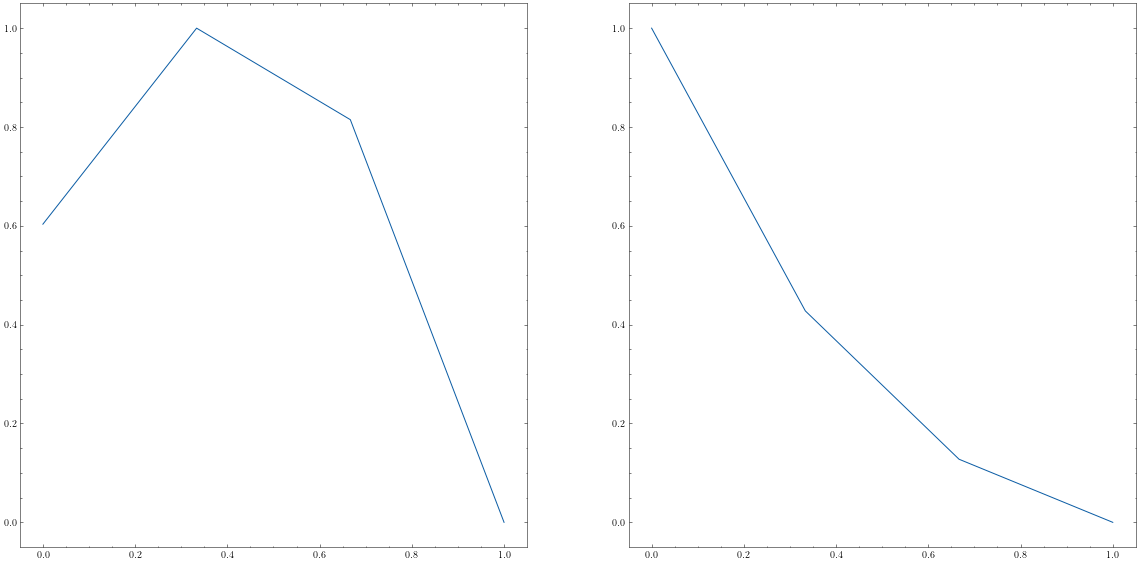

Angle : 3
 Toc = 1053.974096308274
 Tcc : 48.51950377267523


In [11]:

nbclass = 5

Tmsize = [5]
Tsigma = [3]

for msize in Tmsize:
    print("msize = ", msize)
    for sigma in Tsigma:
        print("sigma = ", sigma)

        
        
        # feature_areas, contours, all_labeled_image = otsu_detection(nbclass, sys_image_bis, msize, sigma, sigma)
        blurred_sys = cv2.GaussianBlur(sys_image_bis, (msize, msize), sigmaX = sigma, sigmaY = sigma)
       
        Tcc = []
        Toc = []


        for nclass in range(2, nbclass +1):
            feature_areas, all_contours, all_labeled_image, thresholds = cluster_detection(blurred_sys, nclass)
            
            if len(feature_areas) > 600 and nu < 0.5:
                blurred_sys2 = cv2.medianBlur(sys_image_bis, 5)
                blurred_sys2 = cv2.GaussianBlur(blurred_sys2, (7, 7), sigmaX = 0, sigmaY = 0)
            else: 
                blurred_sys2 = blurred_sys
            
            
            thresholds = threshold_multiotsu(blurred_sys2, classes = nclass) 
            Tcc.append(class_contrast(sys_image_bis, thresholds))
            Toc.append(otsu_criterion(sys_image_bis, thresholds))

        norm_Tcc = (Tcc - np.min(Tcc))/(np.max(Tcc-np.min(Tcc)))
        norm_Toc = (Toc - np.min(Toc))/(np.max(Toc-np.min(Toc)))


        nbthresholds = np.arange(1,nbclass)
        norm_nbthresholds = (nbthresholds - np.min(nbthresholds))/(np.max(nbthresholds-np.min(nbthresholds)))
        fig, (ax1,ax2) = plt.subplots(1,2,figsize = (20,10))
        ax1.plot(norm_nbthresholds, norm_Tcc)
        ax2.plot(norm_nbthresholds, norm_Toc)
        plt.show()

        # print(f"Nombre class : {KneeLocator(range(1, nbclass), Toc, curve='convex', direction='decreasing', S = 1.5).elbow}")

        best_nb_class_elbow = KneeLocator(range(1, nbclass), Toc, curve='convex', direction='decreasing').elbow
        if best_nb_class_elbow != None:
            print("Elbow : ", best_nb_class_elbow + 1)
            print(f" Toc = {Toc[best_nb_class_elbow]}")
            print(f" Tcc : {Tcc[best_nb_class_elbow]}")
        # if best_nb_class == 'None':
        vector1 = np.array([[x1 - x2, y1 - y2] for x1, x2, y1, y2 in zip(norm_nbthresholds[:-2], norm_nbthresholds[1:-1], norm_Tcc[:-2], norm_Tcc[1:-1])])
        vector2 = np.array([[x2 - x1, y2 - y1] for x1, x2, y1, y2 in zip(norm_nbthresholds[1:-1], norm_nbthresholds[2:], norm_Tcc[1:-1], norm_Tcc[2:])])

        # Scalar product 
        prod_scal = np.array([np.dot(v1,v2)  for v1, v2 in zip(vector1, vector2)])

        # Norm calculation
        norm_v1 = np.array([np.linalg.norm(v) for v in vector1])
        norm_v2 = np.array([np.linalg.norm(v) for v in vector2])

        # Cosinus law
        cos_theta = np.clip(prod_scal / (norm_v1 * norm_v2), -1.0, 1.0)

        angles = np.degrees(np.arccos(cos_theta))
        
        best_nb_class_angle = np.argmin(angles) + 2
        print(f"Angle : {best_nb_class_angle + 1}") 
        # print(f"Nombre de classe : {best_nb_class + 1}")
        print(f" Toc = {Toc[best_nb_class_angle]}")
        print(f" Tcc : {Tcc[best_nb_class_angle]}")



### Final detection 

/tmp/ipykernel_2194066/2098061379.py:186: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(feature_areas), np.array(all_contours), np.array(all_labeled_image), thresholds, np.array(all_contours_to_label)


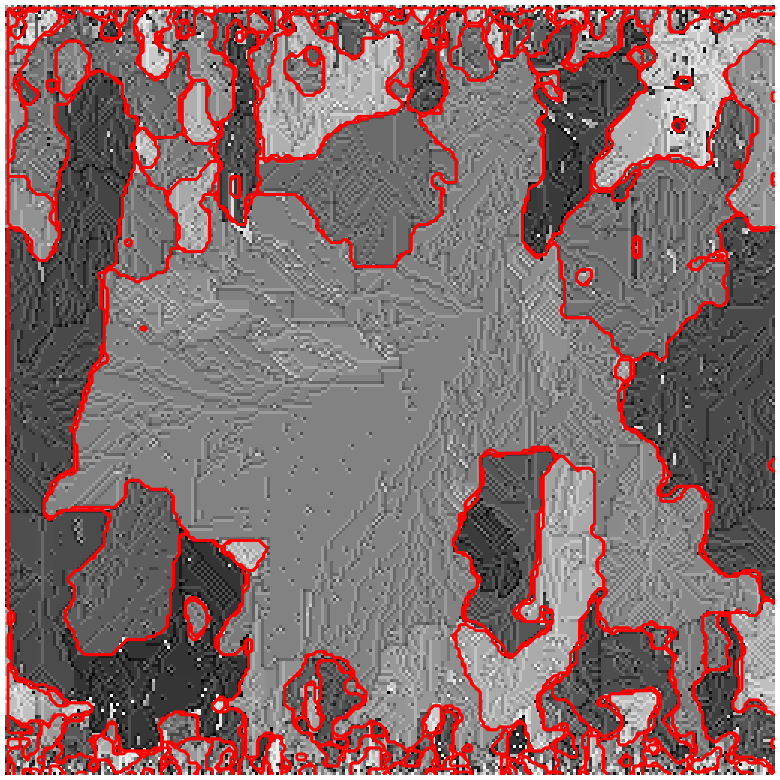

In [4]:
from matplotlib.path import Path

# Tcriterion = [1, 1, 1, 0, 1, 0] # 1: Interclass, 0: Intraclass
# Tnbclass =   [5, 5, 5, 5, 5, 4]
# Tmsize =     [3, 3, 3, 3, 5, 3]
# Tsigma_X =   [0, 0, 0, 0, 3, 2]

nbclass = 4
Tmsize = [3]
Tsigma = [2]
mode_switch = 0
nbsnap = 10
# elements = os.listdir("{}Snapshots/".format(folderpath))
elements = ["nav7000000000_outputB.txt"]
for element in elements[:nbsnap]:
    data = np.loadtxt("{}Snapshots/{}".format(folderpath,element), comments='#')
    sys = data.reshape(L1, L2).T
    sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

    nu = read_parameters(folderpath)[2]
    for msize in Tmsize:
        for sigma in Tsigma:
            nbpatches = []
            #blurred_sys = cv2.GaussianBlur(sys_image_bis, (msize, msize), sigmaX = sigma, sigmaY = sigma)

            total_var  = 0
            nvar = 0

            feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclass, sys_image_bis, msize, sigma, sigma, mode_switch)

            fig, axis = plt.subplots(1, 1, figsize = (10,10))
            axis.imshow(sys_image_bis, cmap='binary')
            for i, contour in enumerate(all_contours):
                    axis.plot(contour[:, 1], contour[:, 0], linewidth= 2, color="red", alpha=1)
            axis.axis('off')
            plt.show()
            if len(all_contours) > 600 and nu < 0.5:
                blurred_sys2 = cv2.medianBlur(sys_image_bis, 5) #Supprime le bruit en raplaçant la valeur par la dmedian des voisines
                    
                feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclass, blurred_sys2, 7,0,0, mode_switch)
                
                fig, axis = plt.subplots(1, 1, figsize = (10,10))
                axis.imshow(sys_image_bis, cmap='binary')
                for i, contour in enumerate(all_contours):
                        axis.plot(contour[:, 1], contour[:, 0], linewidth= 2, color="red", alpha=1)
                axis.axis('off')
                plt.show()
            # else:
            #     feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = second_detection(sys_image_bis, all_contours, all_labeled_image, contour_to_label)
            #     print(feature_areas2)
            #     fig, axis = plt.subplots(1, 1, figsize = (10,10))
            #     axis.imshow(sys_image_bis, cmap='binary')
            #     for i, contour in enumerate(all_contours2):
            #             axis.plot(contour[:, 1], contour[:, 0], linewidth= 2, color="red", alpha=1)
            #     axis.axis('off')
            #     plt.show()

<ipython-input-33-f09d3bb1a012>:187: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(feature_areas), np.array(all_contours), np.array(all_labeled_image), thresholds, np.array(all_contours_to_label)


Ext contour id : 8


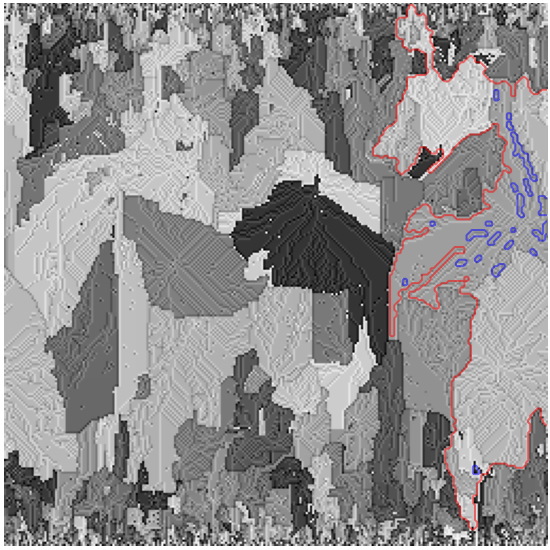

In [39]:
from matplotlib.path import Path
nbclass = 4
Tmsize = [3]
Tsigma = [2]
mode_switch = 0

with open("Otsu_detection.txt", "w") as f:
    for msize in Tmsize:
        f.write("msize = {}\n".format(msize))
        for sigma in Tsigma:
            f.write("sigma = {}\n".format(sigma))
            
            Tnbpatches = []
            #blurred_sys = cv2.GaussianBlur(sys_image_bis, (msize, msize), sigmaX = sigma, sigmaY = sigma)

            total_var  = 0
            nvar = 0
            
            feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclass, sys_image_bis, msize, sigma, sigma, mode_switch)
            if len(all_contours) > 600 and nu < 0.5:
                blurred_sys2 = cv2.medianBlur(sys_image_bis, 5) #Supprime le bruit en raplaçant la valeur par la dmedian des voisines
                
                feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclass, blurred_sys2, 7,0,0, mode_switch)

            Tnbpatches.append(len(feature_areas))
            
            """ fig, axis = plt.subplots(1, 1, figsize = (15,10))
            axis.imshow(sys_image_bis, cmap='binary')
            for i, contour in enumerate(all_contours):
                if contour_to_label[i, 1] == -1:
                    axis.plot(contour[:, 1], contour[:, 0], linewidth= 2, color="blue", alpha=1)
                else:
                    axis.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)
            axis.axis('off')
            plt.axis('off')
            plt.savefig("patches_detection.pdf")
            plt.show() """

            f.write("\n\n")

            """ ########Affichage en couleur de chaque domaine################
            for labeled_image in all_labeled_image:
                fig, ax = plt.subplots(figsize  = (10,10))
                ax.imshow(labeled_image, cmap='inferno')
                ax.axis('off')
                plt.show() """
            
            """ ############Affichage de l'histogram#############
            histo, bins = np.histogram(data, bins=100)
            fig, ax = plt.subplots(figsize = (10,10))
            for threshold in thresholds:
                ax.axvline(threshold/255, color='k', linestyle='-', lw = 2)
            ax.plot(bins[:-1], histo/np.sum(histo), lw = 2)
            para_fig(ax, r'$E$', r'$P(E)$')
            plt.show() """
            
            
            ############On essaie de supprimer les faux petit domaines dans les grands###################
            len_contour = [len(contour) for contour in all_contours]
            id_sorted_len = np.argsort(len_contour)
            id_test_contour = id_sorted_len[-3]
            print("Ext contour id :", id_test_contour)
            
            mask = np.all(contour_to_label == contour_to_label[id_test_contour,:], axis=1)
            f_contours = all_contours[mask]
            
            """ print(np.shape(contour_to_label))
            print(np.shape(all_contours))
            print(contour_to_label[id_test_contour,:])
            print(np.shape(mask))
            print(contour_to_label[mask]) """
            
            fig, ax = plt.subplots(figsize = (10,10))
            ax.imshow(sys_image_bis, cmap='binary')
            for i, contour in enumerate(f_contours): #First item should always be the external contour
                if i==0:
                    ax.plot(contour[:, 1], contour[:, 0], lw=2, color="red", alpha=0.5)
                else:
                    ax.plot(contour[:, 1], contour[:, 0], lw=2, color="blue", alpha=0.5)
            
            
            """ points = np.array((np.arange(L1), np.arange(L2)))

            for _, contour_int1 in enumerate(f_contours[1:]):
                #On regarde si la moyenne est la même que pour le grand patch
                #Regardes tout les points dans le grand patch (enlever ceux des petit contenus)
                #Calc moyenne dedans 
                #Calc moyenne des petits
                #Si la même on trouve le domaine en dessous et on le supprime
                
                countour_ext1 = f_contours[0]
                external_path = Path(countour_ext1)
                inside_points = external_path.contains_points(points)
                
                external_path = Path(contour_int1)
                inside_points = external_path.contains_points(points)
                mean_inside_sys_image_bis = np.mean(sys_image_bis[inside_points])
                
                
                for i in range(len(all_labeled_image)):
                    if i == contour_to_label[id_test_contour, 1]:
                        continue
                    
                    labeled_image = all_labeled_image[i]
                    f_labeled_image = labeled_image[inside_points]
                    if np.any(f_labeled_image!= 0):
                        mask = f_labeled_image!= 0
                        f2_labeled_image = f_labeled_image[mask]
                        
                        
                    print(np.mean(labeled_image[inside_points]))
                    
                    if np.any(external_path.contains_points(all_labeled_image[i])):
                        ax.plot(all_labeled_image[i][:, 1], all_labeled_image[i][:, 0], lw=2, color="green", alpha=0.5)

                for _, contours_ext2 in enumerate(all_contours[~mask]):
                    inside = external_path.contains_points(contours_ext2)
                    if np.any(inside):
                        if len(contours_ext2) > 10 * len(contour_int1):
                            continue
                        ax.plot(contours_ext2[:, 1], contours_ext2[:, 0], lw=2, color="green", alpha=0.5)
                else: 
                    print("No inside countour found") """
            
            plt.axis('off')
            plt.show()
                    
                    
            
            
          


# On moyenne la detection de patch sur plusieurs patch pour avoir une bonne statistique

In [ ]:
def otsu_criterion(image, thresholds):

    regions = np.digitize(image, bins=thresholds)
    total_variance = 0
    
    for i in range(len(thresholds) + 1):
        mask = regions == i
        if np.any(mask):
            variance = np.var(image[mask])
            total_variance += variance
    
    return total_variance

def class_contrast(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    means = [np.mean(image[regions == i]) for i in range(len(thresholds) + 1)]
    contrast = np.std(means)  # Dispersion des moyennes
    return contrast

def snr_metric(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    foreground = image[regions > 0]  # Patches détectés
    background = image[regions == 0]  # Fond

    signal = np.mean(foreground)
    noise = np.std(background) if np.any(background) else 1  # Éviter division par 0

    return signal / noise

def process_detection(folderpath, nbclasse, nbsnap):
    L1 = read_parameters(folderpath)[0]
    L2 = read_parameters(folderpath)[1]
    nu = read_parameters(folderpath)[2]

    lin_bins = np.arange(0, L1 * L2)
    histo = np.zeros(len(lin_bins) - 1)
    # file = f"{folderpath}nav100000000000_outputB.txt"
    # file = f"{folderpath}Snapshots/nav6000000000_outputB.txt"


    elements = os.listdir("{}Snapshots/".format(folderpath))
    print(len(elements))
    for element in elements[:nbsnap]:
        data = np.loadtxt("{}Snapshots/{}".format(folderpath,element), comments='#')
        sys = data.reshape(L1, L2).T
        sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV
        image = cv2.GaussianBlur(sys_image_bis, (3, 3), sigmaX = 5, sigmaY = 5)
        
        feature_areas = otsu_detection(nbclasse, image)
        if len(feature_areas) > 600 and nu < 0.5:
            image = cv2.medianBlur(sys_image_bis, 3)
            image = cv2.GaussianBlur(image, (3, 3), sigmaX = 3, sigmaY = 3)
            
            feature_areas = otsu_detection(nbclasse, image, switch = 1)


        histo += np.histogram(feature_areas, bins=lin_bins)[0]
        
    return histo


def otsu_detection(nbclasse, image, switch = 0):
    max_interclasse = 0
    max_nbclasse = 0
    for n in range(2,nbclasse):
        
        thresholds = threshold_multiotsu(image, classes = n)
        regions = np.digitize(image, bins=thresholds)
        # quality = otsu_criterion(sys_image_bis, thresholds)
        # print("Variance intra-classe totale :", quality)
        contrast = class_contrast(image, thresholds)
        # print("n = {}, Contraste inter-classes :{}".format(n, contrast))
        
        if contrast > max_interclasse:
            max_interclasse = contrast
            max_nbclasse = n

    # max_nbclasse = 5
    thresholds = threshold_multiotsu(image, classes = max_nbclasse)
    regions = np.digitize(image, bins=thresholds)

    feature_areas = []
    # regrouped_contours = []


    if switch:
        fig, ax = plt.subplots(figsize = (10,10))
        ax.imshow(sys_image_bis, cmap='binary')


    for i in range (1, max_nbclasse + 1):

        mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
        masked_image = np.where(mask, 1, -1)

        # Appliquer un filtre Gaussien sur les pixels valides
        smoothed_image = filters.gaussian(masked_image, sigma=1)

        original = smoothed_image
        thres = threshold_otsu(smoothed_image) #Trouve un seuil entre le background et les patches
        binary = original > thres
        binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
        labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
        feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions


        contours = measure.find_contours(binary_closed, level=0.5)
        if switch:
            for contour in contours:
                ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)
      
    if switch:      
        plt.axis('off')
        plt.show()
    
    return feature_areas
    

##  Pour un fichier

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.draw import polygon
from skimage import io, filters, measure, segmentation, color, data
from scipy import ndimage

from scipy.ndimage import label
from scipy.ndimage.morphology import binary_closing
import matplotlib.pylab as plt
from skimage.filters import threshold_multiotsu, threshold_otsu

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '../Fct_scripts')))
from tools import *
from macro import *



folderpath = "/data1/DATA_Duplat/Brut/Patch_detection/Pa1n4/"

nbclasse = 6


L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]

lin_bins = np.arange(0, L1 * L2)
histo = np.zeros(len(lin_bins) - 1)

# file = f"{folderpath}nav100000000000_outputB.txt"
# file = f"{folderpath}Snapshots/nav6000000000_outputB.txt"


elements = os.listdir("{}Snapshots/".format(folderpath))
print(len(elements))
for element in elements[5:10]:
    data = np.loadtxt("{}Snapshots/{}".format(folderpath,element), comments='#')
    sys = data.reshape(L1, L2).T
    sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV
    
    image = cv2.GaussianBlur(sys_image_bis, (3, 3), sigmaX = 3, sigmaY = 3)
        
    feature_areas = otsu_detection(nbclasse, image, switch = 1)
    
    if len(feature_areas) > 600 and nu < 0.5:
        image = cv2.medianBlur(sys_image_bis, 3)
        image = cv2.GaussianBlur(image, (3, 3), sigmaX = 3, sigmaY = 3)
        
        feature_areas = otsu_detection(nbclasse, image, switch = 1)

    


    

# On test 2D otsu thresholding

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def multi_otsu_2d(image, classes=4, kernel_size=3):
    """
    Applique la méthode Multi-Otsu 2D pour segmenter une image en plusieurs classes.

    Parameters:
        - image : ndarray, image en niveaux de gris
        - classes : int, nombre de classes souhaitées
        - kernel_size : int, taille du voisinage pour la moyenne locale

    Returns:
        - thresholds : liste des seuils trouvés
        - segmented : image segmentée en `classes` régions
    """
    # Convertir en niveaux de gris si l'image est en couleur
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 1. Calculer la moyenne locale des intensités
    mean_neighborhood = cv2.blur(image, (kernel_size, kernel_size))

    # 2. Construire un histogramme 2D
    hist_2d, x_bins, y_bins = np.histogram2d(image.ravel(), mean_neighborhood.ravel(), bins=256, range=[[0, 255], [0, 255]])
    
    plt.figure(figsize=(8, 6))
    plt.imshow(hist_2d.T, origin='lower', cmap='hot', aspect='auto', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]])
    plt.colorbar(label="Nombre de pixels")
    plt.xlabel("Valeur du pixel")
    plt.ylabel("Moyenne du voisinage")
    plt.title("Histogramme 2D de l'image")
    plt.show()

    # 3. Trouver les seuils optimaux en utilisant Multi-Otsu
    thresholds = threshold_multiotsu(hist_2d, classes=classes)

    # 4. Segmenter l'image en utilisant les seuils trouvés
    segmented = np.digitize(image, bins=thresholds)

    return thresholds, segmented




# Charger une image bruitée en niveaux de gris
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD1n14/"

L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]

file = f"{folderpath}nav100000000000_outputB.txt"
data = np.loadtxt(file, comments='#')
sys = data.reshape(L1, L2).T
sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

image = cv2.GaussianBlur(sys_image_bis, (3, 3), sigmaX = 5, sigmaY = 5)

# Appliquer la méthode Otsu 2D
thresholds, segmented_image = multi_otsu_2d(image, classes=5)

# Affichage des résultats

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sys_image_bis, cmap='gray')
ax[0].set_title('Image originale')
ax[1].imshow(segmented_image, cmap='jet')
ax[1].set_title(f'Image segmentée (5 classes)')
plt.show()



#   Correlation taille patch avec taille avalanche